In [2]:
from datetime import date
import time

import warnings
warnings.filterwarnings(action='once')


from fidelity import *
from povm import *
%matplotlib inline


today = date.today()
datestr = today.strftime("%y%m%d")


# Hyperparameters
Nq = 3

povm = POVM('pauli6')
Na = povm.Na

In [6]:
data_fname = 'data/ibmq-ghz-Nq3.npy'

data = np.load(data_fname)

np.random.shuffle(data)

Ns = len(data)



# MLE reconstruction

In [7]:
ptab = np.zeros((Na**Nq), dtype=float)

for ns in range(Ns):
    o = basestr2int(data[ns], Na)
    ptab[o] += 1./Ns

In [8]:
from MLE import *

dm_mle = MLE_DM(ptab, Nq, povm)

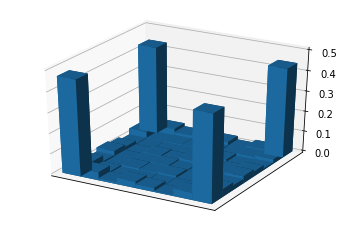

In [9]:
fig_model = plotDM(dm_mle, Nq)

plt.show(fig_model)

# AQT reconstruction

In [12]:
from ann import *


print(torch.cuda.is_available())
device = torch.device("cuda:0")

True


In [13]:
split = 0.8
traindata = data[:int(len(data)*split)]
testdata = data[int(len(data)*split):]

/home/peter/Box/CMT/projects/ml/python/ann.py:443: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  nn.init.xavier_uniform(p)
/home/peter/.local/lib/python3.6/site-packages/torch/nn/_reduction.py:43: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


1 : 1.6001263393296137
2 : 1.4314715266227722
3 : 1.3451622128486633
4 : 1.3162026471561856
5 : 1.3052832682927449
6 : 1.2997192806667752
7 : 1.2953106297387018
8 : 1.2929526170094807
9 : 1.2916681965192158
10 : 1.289270646042294
11 : 1.287122110525767
12 : 1.284372587998708
13 : 1.2830620606740315
14 : 1.2833057641983032
15 : 1.2814540995491877
16 : 1.2815810706880357
17 : 1.2803668710920546
18 : 1.279396076997121
19 : 1.2778721517986722
20 : 1.2786618603600397
21 : 1.2770849135186937
22 : 1.277172373400794
23 : 1.2771405776341755
24 : 1.2762131094932556
25 : 1.275747021039327
26 : 1.2756682104534574
27 : 1.2753952807850308
28 : 1.2748026318020291
29 : 1.2740976611773174
30 : 1.274023711681366
31 : 1.273504568470849
32 : 1.2733492453893025
33 : 1.2737960351838007
34 : 1.2734364072481792
35 : 1.273828234937456
36 : 1.2728672160042658
37 : 1.2723429600397747
38 : 1.2740965419345431
39 : 1.273605055279202
40 : 1.2735456162028842
41 : 1.2727309929000006
42 : 1.2732422351837158
43 : 1.2724

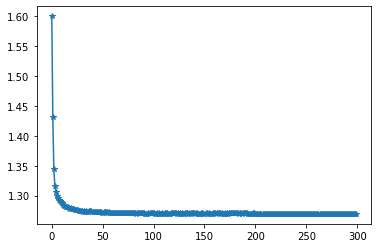

In [14]:
# Train model
fname = 'mod/%s-ghz-ibmq-Nq%i-Ns%i.mod'%(datestr, Nq,Ns)

model = InitializeModel(Nq, Nlayer=2, dmodel=64, Nh=4, Na=6, dropout=0.0).to(device)

t = time.time()
model, losses = TrainModel(model, traindata, testdata, device, smoothing=0.0, batch_size=30,lr=1e-4,Nep=300)
print('Took %f minutes'%((time.time()-t)/60))

model.to('cpu')
torch.save(model, fname)
plt.plot(losses,'-*')


In [15]:
# model = torch.load(f='mod/%s-ghz-ibmq-Nq%i-Ns%i.mod'%(datestr, Nq,Ns))

ptab_model = POVMProbTable(model)

dm8 = np.zeros((8, 2**Nq, 2**Nq), dtype=complex)

for xyz in range(8):
    dm8[xyz] = GetDMFull(ptab_model, Nq, POVM('pauli6', xyz))



In [22]:
_, negeig, dm_model = GetBestDM(dm8)

print([min(np.linalg.eigvals(dm8[i]).real) for i in range(8)])
print(np.linalg.eigvals(dm_model).real)

[-0.1612856430899609, -0.17074947122036607, -0.11819433154613163, -0.152815682960753, -0.16716443964498753, -0.16825122043559385, -0.19402617612920484, -0.19604751578928328]
[ 0.93094739  0.13322013  0.08363205  0.03602143 -0.06904413 -0.07389875
 -0.03666655 -0.00421158]


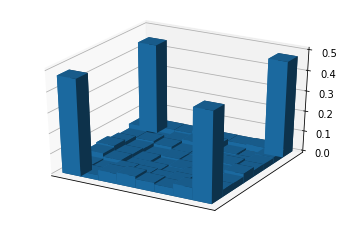

In [7]:
dm_model = np.load('dm/dm_AQT_Nq3.npy')

fig_model = plotDM(dm_model, Nq)
plt.show(fig_model)

# np.save('dm/dm_AQT_Nq3.npy', dm_model)
# fig_model.savefig('figures/ibmq-AQT.pdf', dpi=300, frameon=True,bbox_inches="tight")

In [9]:
from povm import *
from qiskit.quantum_info import state_fidelity

Ne = 4
rhoKB = np.zeros((Ne, 2*Nq), dtype=int)
rhoAmp = np.zeros((Ne), dtype=complex)

# Pure GHZ state
rhoKB[1, :] = 1
rhoKB[2, :Nq] = 1
rhoKB[3, Nq:] = 1

rhoAmp[0] = 0.5
rhoAmp[1] = 0.5
rhoAmp[2] = 0.5
rhoAmp[3] = np.conj(rhoAmp[2])

density = {}
density['KB'] = rhoKB
density['Amp'] = rhoAmp

dm_ghz = Struct2DM(density)

print(state_fidelity(dm_model, dm_ghz))

0.9172594077128736


# Frequency histogram reconstruction

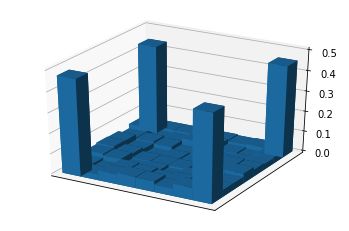

In [11]:
dm8 = np.zeros((8, 2**Nq, 2**Nq), dtype=complex)
for xyz in range(8):
    dm8[xyz] = GetDMSample(POVM('pauli6', xyz), data)
    
_, negeig, dm_sample = GetBestDM(dm8)

fig_sample = plotDM(dm_sample, Nq)
plt.show(fig_sample)

# Quantum fidelity

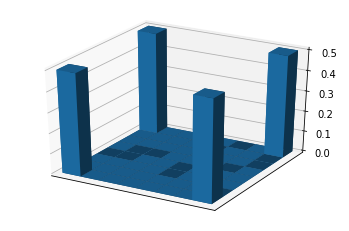

In [25]:
dm_ghz = np.zeros((2**Nq, 2**Nq), dtype=complex)
dm_ghz[0,0] = 1./2
dm_ghz[0,-1] = 1./2
dm_ghz[-1,0] = 1./2
dm_ghz[-1,-1] = 1./2

fig_ghz = plotDM(dm_ghz, Nq)
plt.show(fig_ghz)

In [29]:
from qiskit.quantum_info import state_fidelity

dm_ibmq = np.load('dm/dm_ibmq_Nq3.npy')
dm_aqt = np.load('dm/dm_AQT_Nq3.npy')

print(state_fidelity(dm_ghz, dm_ibmq))
print(state_fidelity(dm_ghz, dm_aqt))
print(state_fidelity(dm_ibmq, dm_aqt))

0.896872826590801
0.9172594077128738
1.0432705243304106
